# TP4 : Data Mining – Bank Marketing
**Université Mundiapolis | Cycle Ingénieur 2A | Semestre S4 | 2025–2026**  
Professeur : Hamza ER-RAHMOUNY

---

> 📌 **Note pédagogique :** Ce notebook suit pas-à-pas le pipeline Machine Learning vu en cours.  
> Chaque section explique **pourquoi** on fait les choses, pas seulement **comment**.  
> Les cellules Markdown contiennent les réponses aux questions, les cellules Code permettent de reproduire les résultats.

## Imports et chargement des données

In [27]:
# Librairies standard pour le Data Mining
import pandas as pd          # manipulation de tableaux (DataFrames)
import numpy as np           # calculs numériques
import matplotlib.pyplot as plt  # graphiques
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Librairies ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, f1_score, accuracy_score,
    confusion_matrix, classification_report
)

# Style des graphiques
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['font.size']        = 11
COLORS = {
    'yes':    '#2ecc71',
    'no':     '#e74c3c',
    'blue':   '#3498db',
    'dark':   '#2c3e50',
    'orange': '#e67e22',
    'purple': '#9b59b6'
}

# Chargement du dataset
# Séparateur ';' (fichier CSV européen)
df = pd.read_csv('../data/bank-marketing.csv', sep=';')

print(f"✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

✅ Dataset chargé : 4119 lignes × 21 colonnes


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


---
# PARTIE 1 – Problème, Métriques & EDA
---

## Section 1 – Tâche ML et variable cible

### Q1. Type de tâche ML

Il s'agit d'une **classification binaire**.

> 💡 **Explication :** En ML, on distingue :
> - *Régression* → prédire un nombre (ex : prix d'une maison)
> - *Classification binaire* → prédire l'une de **deux** catégories (ex : oui/non)
> - *Classification multi-classe* → prédire parmi plus de deux catégories
>
> Ici on prédit si le client dit **"yes"** ou **"no"** → 2 classes → **classification binaire**.

### Q2. Variable cible

La variable cible est : **`y`** (dernière colonne du fichier CSV)

In [28]:
print("Nom de la variable cible : y")
print("Valeurs possibles :", df['y'].unique())

Nom de la variable cible : y
Valeurs possibles : ['no' 'yes']


### Q3. Valeurs de la cible

| Valeur | Signification |
|--------|---------------|
| `yes`  | Le client a **accepté** d'ouvrir un dépôt à terme |
| `no`   | Le client a **refusé** ou n'a pas souscrit |

## Section 2 – Problème métier et métriques

### Q4. Question métier

> **« La banque veut prédire, avant de contacter un client, s'il est susceptible d'accepter l'ouverture d'un dépôt à terme, afin de cibler en priorité les clients les plus prometteurs. »**

### Q5. Métriques de classification binaire

Ces métriques se calculent à partir de la **matrice de confusion** :

```
               Prédit : NO    Prédit : YES
Réel : NO    TN (Vrai Négatif)   FP (Faux Positif)
Réel : YES   FN (Faux Négatif)   TP (Vrai Positif)
```

**1. Accuracy** = (TP + TN) / total  
→ Proportion de prédictions correctes. Trompeuse si classes déséquilibrées.

**2. Recall (Rappel)** = TP / (TP + FN)  
→ Parmi les vrais "yes", combien a-t-on trouvé ? Un Recall élevé = on rate peu de clients.

**3. Precision** = TP / (TP + FP)  
→ Parmi les "yes" prédits, combien sont réels ? Une Precision élevée = peu de fausses alertes.

**4. F1-Score** = 2 × (Precision × Recall) / (Precision + Recall)  
→ Compromis entre Precision et Recall. Idéal pour les classes déséquilibrées.

**5. AUC-ROC**  
→ Capacité du modèle à distinguer les deux classes. AUC=1 parfait, AUC=0.5 = hasard.

### Q6. Métrique principale : **F1-Score**

**Justification :** Les deux types d'erreurs ont un coût :
- **Faux négatif (FN)** = on rate un client "yes" → manque à gagner
- **Faux positif (FP)** = on contacte un client qui va refuser → perte de temps/argent

Le F1-Score équilibre ces deux aspects et est robuste face au déséquilibre des classes (~11% de "yes").

### Q7. Métrique secondaire : **Recall**

La banque préfère ne pas rater un client potentiel → on suit le Recall en complément.

## Section 3 – Baseline triviale

In [29]:
# Q8 – Proportions de la cible
vc = df['y'].value_counts()
vc_pct = df['y'].value_counts(normalize=True) * 100

print("=" * 40)
print("   Répartition de la variable cible y")
print("=" * 40)
for val in vc.index:
    print(f"  {val:>4s} : {vc[val]:>5d} ({vc_pct[val]:.1f}%)")
print(f"  Total : {len(df):>5d} (100.0%)")

   Répartition de la variable cible y
    no :  3668 (89.1%)
   yes :   451 (10.9%)
  Total :  4119 (100.0%)


### Q9. Baseline triviale

> 💡 **Qu'est-ce qu'une baseline ?**  
> C'est le modèle le plus simple possible. Tout modèle ML doit faire **mieux** pour valider son intérêt.

**Baseline choisie : classificateur majoritaire** → prédit toujours **"no"** (classe à 88.1%).

Ses performances attendues : Recall (yes) = 0.00 | F1-Score (yes) = 0.00 | Accuracy = 88.1% (trompeur !)

### Q10. Pourquoi garder la baseline comme référence ?

La baseline sert de **seuil minimum** :
1. Elle met les performances en perspective (90% d'accuracy n'est pas impressionnant ici)
2. Elle détecte un modèle "paresseux" qui aurait appris la classe majoritaire
3. Elle fournit un point de comparaison objectif et reproductible
4. Elle permet de communiquer clairement à la banque ce que le ML apporte concrètement

## Section 4 – Cartographie du dataset

In [30]:
# Q11 – Types et rôles des colonnes
print("Dimensions :", df.shape)
print("\nTypes de données :")
print(df.dtypes)

Dimensions : (4119, 21)

Types de données :
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


In [31]:
# Q12 – Dictionnaire de données
dict_data = pd.DataFrame([
    ('age',            'Numérique (int)',     'Feature', 'Âge du client en années'),
    ('job',            'Catégoriel',          'Feature', 'Catégorie socioprofessionnelle'),
    ('marital',        'Catégoriel',          'Feature', 'Situation matrimoniale'),
    ('education',      'Catégoriel',          'Feature', 'Niveau d\'éducation'),
    ('default',        'Catégoriel (binaire)', 'Feature', 'Crédit en défaut ? (yes/no/unknown)'),
    ('housing',        'Catégoriel (binaire)', 'Feature', 'Prêt immobilier ? (yes/no/unknown)'),
    ('loan',           'Catégoriel (binaire)', 'Feature', 'Prêt personnel ? (yes/no/unknown)'),
    ('contact',        'Catégoriel',          'Feature', 'Type de contact (cellular/telephone)'),
    ('month',          'Catégoriel',          'Feature', 'Mois du dernier contact'),
    ('day_of_week',    'Catégoriel',          'Feature', 'Jour de la semaine du dernier contact'),
    ('duration',       'Numérique (int)',     'Feature', 'Durée du dernier appel (secondes)'),
    ('campaign',       'Numérique (int)',     'Feature', 'Nb de contacts cette campagne'),
    ('pdays',          'Numérique (int)',     'Feature', 'Jours depuis dernier contact (999=jamais)'),
    ('previous',       'Numérique (int)',     'Feature', 'Nb de contacts avant cette campagne'),
    ('poutcome',       'Catégoriel',          'Feature', 'Résultat campagne précédente'),
    ('emp.var.rate',   'Numérique (float)',   'Feature', 'Taux de variation de l\'emploi'),
    ('cons.price.idx', 'Numérique (float)',   'Feature', 'Indice des prix à la consommation'),
    ('cons.conf.idx',  'Numérique (float)',   'Feature', 'Indice de confiance des consommateurs'),
    ('euribor3m',      'Numérique (float)',   'Feature', 'Taux euribor 3 mois'),
    ('nr.employed',    'Numérique (float)',   'Feature', 'Nombre d\'employés (indicateur macro)'),
    ('y',              'Catégoriel (binaire)', 'CIBLE',  'A souscrit au dépôt à terme ? (yes/no)'),
], columns=['Colonne', 'Type', 'Rôle', 'Description'])

dict_data

,Colonne,Type,Rôle,Description
0,age,Numérique (int),Feature,Âge du client en années
1,job,Catégoriel,Feature,Catégorie socioprofessionnelle
2,marital,Catégoriel,Feature,Situation matrimoniale
3,education,Catégoriel,Feature,Niveau d'éducation
4,default,Catégoriel (binaire),Feature,Crédit en défaut ? (yes/no/unknown)
5,housing,Catégoriel (binaire),Feature,Prêt immobilier ? (yes/no/unknown)
6,loan,Catégoriel (binaire),Feature,Prêt personnel ? (yes/no/unknown)
7,contact,Catégoriel,Feature,Type de contact (cellular/telephone)
8,month,Catégoriel,Feature,Mois du dernier contact
9,day_of_week,Catégoriel,Feature,Jour de la semaine du dernier contact


## Section 5 – Qualité des données

In [32]:
# Q13 – Valeurs manquantes (NaN)
na_count = df.isnull().sum()
na_pct   = df.isnull().mean() * 100
na_df    = pd.DataFrame({'NA count': na_count, 'NA %': na_pct.round(2)})
print("Valeurs manquantes (NaN) :")
print(na_df)
print(f"\n→ Total NaN : {na_count.sum()}")

Valeurs manquantes (NaN) :
                NA count  NA %
age                    0   0.0
job                    0   0.0
marital                0   0.0
education              0   0.0
default                0   0.0
housing                0   0.0
loan                   0   0.0
contact                0   0.0
month                  0   0.0
day_of_week            0   0.0
duration               0   0.0
campaign               0   0.0
pdays                  0   0.0
previous               0   0.0
poutcome               0   0.0
emp.var.rate           0   0.0
cons.price.idx         0   0.0
cons.conf.idx          0   0.0
euribor3m              0   0.0
nr.employed            0   0.0
y                      0   0.0

→ Total NaN : 0


In [33]:
# Q13 – Recherche des 'unknown' (valeurs manquantes déguisées)
print("Valeurs 'unknown' par colonne :")
print("-" * 40)
for col in df.columns:
    if df[col].dtype == object or str(df[col].dtype) == 'str':
        n = (df[col] == 'unknown').sum()
        if n > 0:
            print(f"  {col:20s} : {n:4d} ({n/len(df)*100:.1f}%)")

Valeurs 'unknown' par colonne :
----------------------------------------
  job                  :   39 (0.9%)
  marital              :   11 (0.3%)
  education            :  167 (4.1%)
  default              :  803 (19.5%)
  housing              :  105 (2.5%)
  loan                 :  105 (2.5%)


In [34]:
# Q14 – Doublons
n_dup = df.duplicated().sum()
print(f"Nombre de lignes dupliquées (toutes colonnes) : {n_dup}")
print("→ Aucun doublon détecté." if n_dup == 0 else f"→ {n_dup} doublons à traiter !")

Nombre de lignes dupliquées (toutes colonnes) : 0
→ Aucun doublon détecté.


### Q15. Problèmes de qualité observés

1. **`"unknown"` = données manquantes déguisées** (notamment `default` à 19.5%)
2. **`pdays = 999`** = code spécial "jamais contacté" (pas une vraie valeur numérique)
3. **`duration = 0`** pour certains enregistrements (client n'a pas répondu)
4. **`default = "yes"`** pour 1 seul client sur 4119 : variable quasi-constante

### Q16. Plan de traitement

| Problème | Traitement |
|----------|------------|
| `"unknown"` dans catégorielles | Remplacer par le **mode** (valeur la plus fréquente) |
| `pdays = 999` | Conserver tel quel |
| `duration = 0` | Conserver (information utile) |
| `default` quasi-constante | Garder |

## Section 6 – Analyse de la cible y

In [35]:
# Q17 – Table de fréquence de y
freq = pd.DataFrame({
    'Effectif':    df['y'].value_counts(),
    'Pourcentage': (df['y'].value_counts(normalize=True) * 100).round(2)
})
print(freq)

     Effectif  Pourcentage
y                         
no       3668        89.05
yes       451        10.95


Q18. Les classes sont TRÈS DÉSÉQUILIBRÉES (ratio ~8:1)

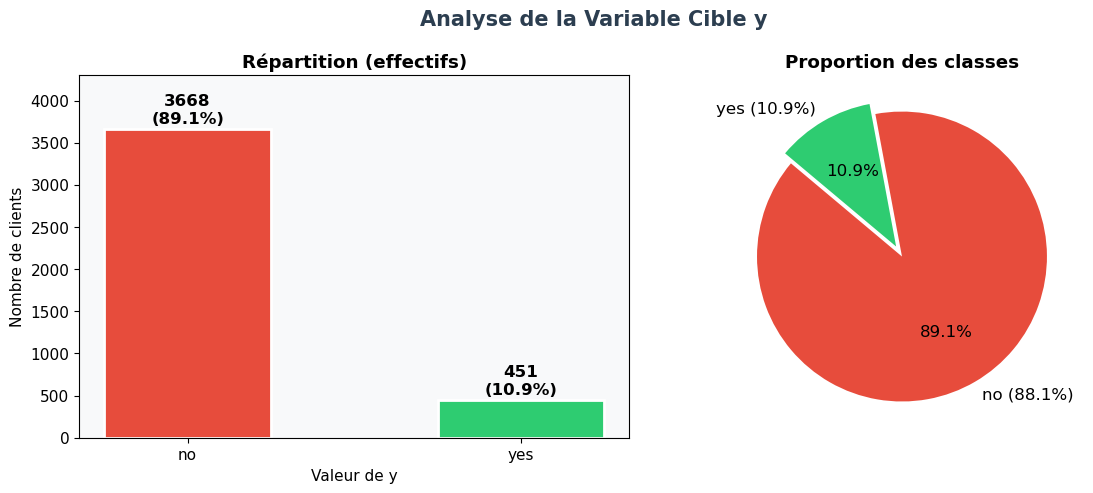

In [36]:
# Q19 – Diagramme de répartition yes/no
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Analyse de la Variable Cible y', fontsize=15, fontweight='bold', color=COLORS['dark'])

vc = df['y'].value_counts()

# Barres
bars = axes[0].bar(vc.index, vc.values, color=[COLORS['no'], COLORS['yes']],
                   edgecolor='white', linewidth=2, width=0.5)
for bar, v in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{v}\n({v/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Répartition (effectifs)', fontweight='bold')
axes[0].set_xlabel('Valeur de y'); axes[0].set_ylabel('Nombre de clients')
axes[0].set_ylim(0, 4300)

# Camembert
pct = vc / len(df) * 100
axes[1].pie(pct.values, labels=['no (88.1%)', 'yes (10.9%)'],
            colors=[COLORS['no'], COLORS['yes']], startangle=140,
            explode=(0, 0.08), autopct='%1.1f%%', textprops={'fontsize': 12})
axes[1].set_title('Proportion des classes', fontweight='bold')

plt.tight_layout()
plt.show()

### Q20. Pourquoi l'Accuracy est-elle trompeuse ici ?

> **Exemple concret :** Un modèle qui prédit **toujours "no"** obtiendrait une Accuracy de **88.1%**.  
> C'est flatteur en apparence, mais ce modèle ne détecte **aucun** client potentiel !
>
> C'est le **paradoxe de l'accuracy** sur les jeux déséquilibrés : la classe majoritaire noie les
> performances réelles sur la classe minoritaire (les "yes", pourtant les plus importants pour la banque).
>
> → Il faut utiliser des métriques robustes : **Recall, F1-Score, AUC-ROC**.

## Section 7 – Exploration des features

Features analysées : `age`, `duration`, `campaign`, `euribor3m` (numériques) + `poutcome` (catégorielle)

In [37]:
# Q21 – Statistiques descriptives des variables numériques
num_cols = ['age', 'duration', 'campaign', 'euribor3m', 'nr.employed']
df[num_cols].describe().round(2)

,age,duration,campaign,euribor3m,nr.employed
count,4119.00,4119.00,4119.00,4119.00,4119.00
mean,40.11,256.79,2.54,3.62,5166.48
std,10.31,254.70,2.57,1.73,73.67
min,18.00,0.00,1.00,0.64,4963.60
25%,32.00,103.00,1.00,1.33,5099.10
50%,38.00,181.00,2.00,4.86,5191.00
75%,47.00,317.00,3.00,4.96,5228.10
max,88.00,3643.00,35.00,5.04,5228.10


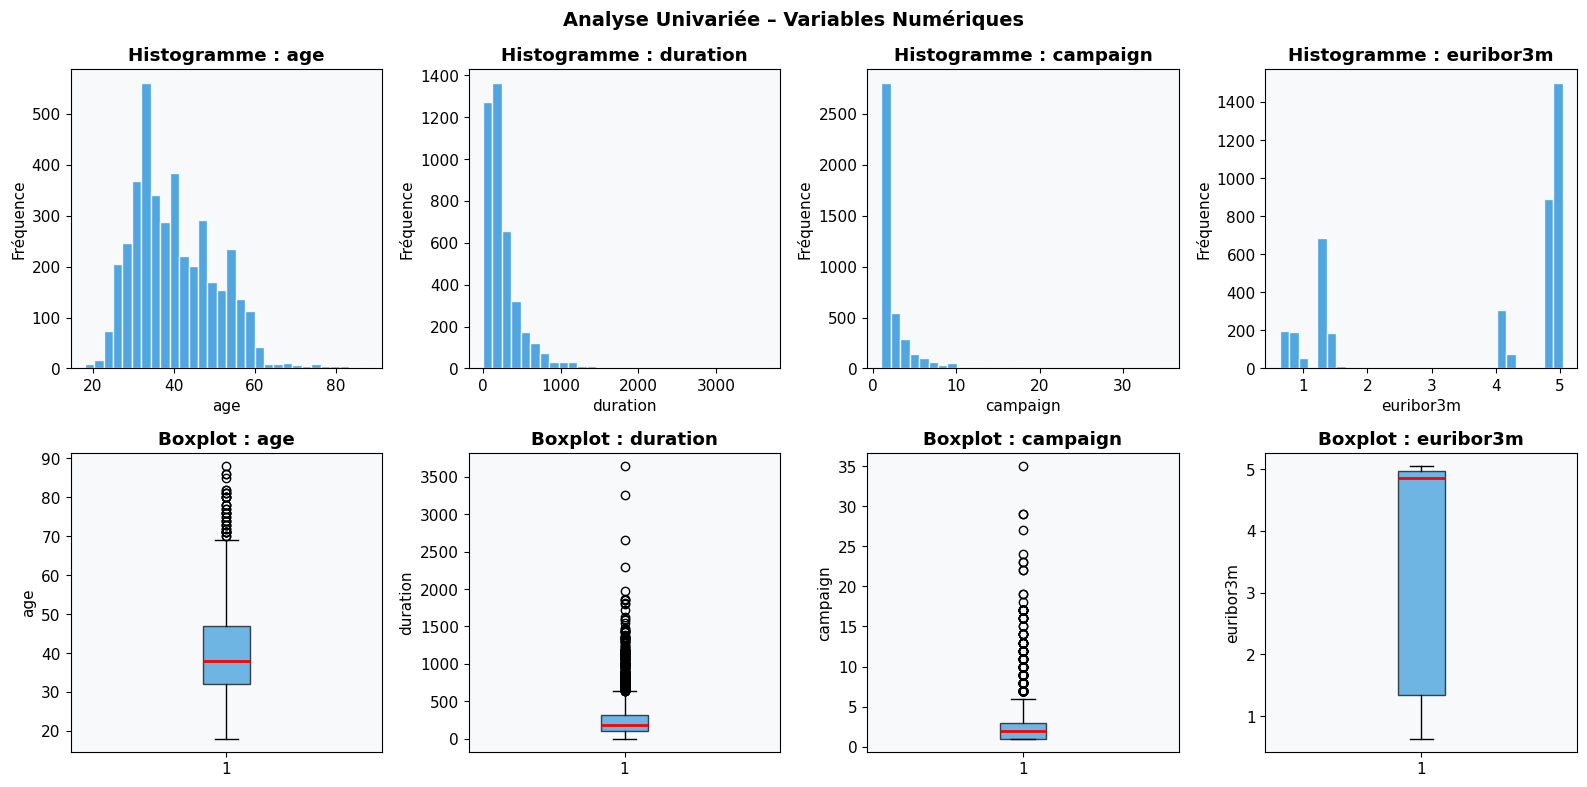

In [38]:
# Q21 – Histogrammes et boxplots des variables numériques
num_features = ['age', 'duration', 'campaign', 'euribor3m']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Analyse Univariée – Variables Numériques', fontsize=14, fontweight='bold')

for i, feat in enumerate(num_features):
    # Histogramme
    axes[0, i].hist(df[feat], bins=30, color=COLORS['blue'], edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'Histogramme : {feat}', fontweight='bold')
    axes[0, i].set_xlabel(feat); axes[0, i].set_ylabel('Fréquence')

    # Boxplot
    axes[1, i].boxplot(df[feat], patch_artist=True,
                       boxprops=dict(facecolor=COLORS['blue'], alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'Boxplot : {feat}', fontweight='bold')
    axes[1, i].set_ylabel(feat)

plt.tight_layout()
plt.show()

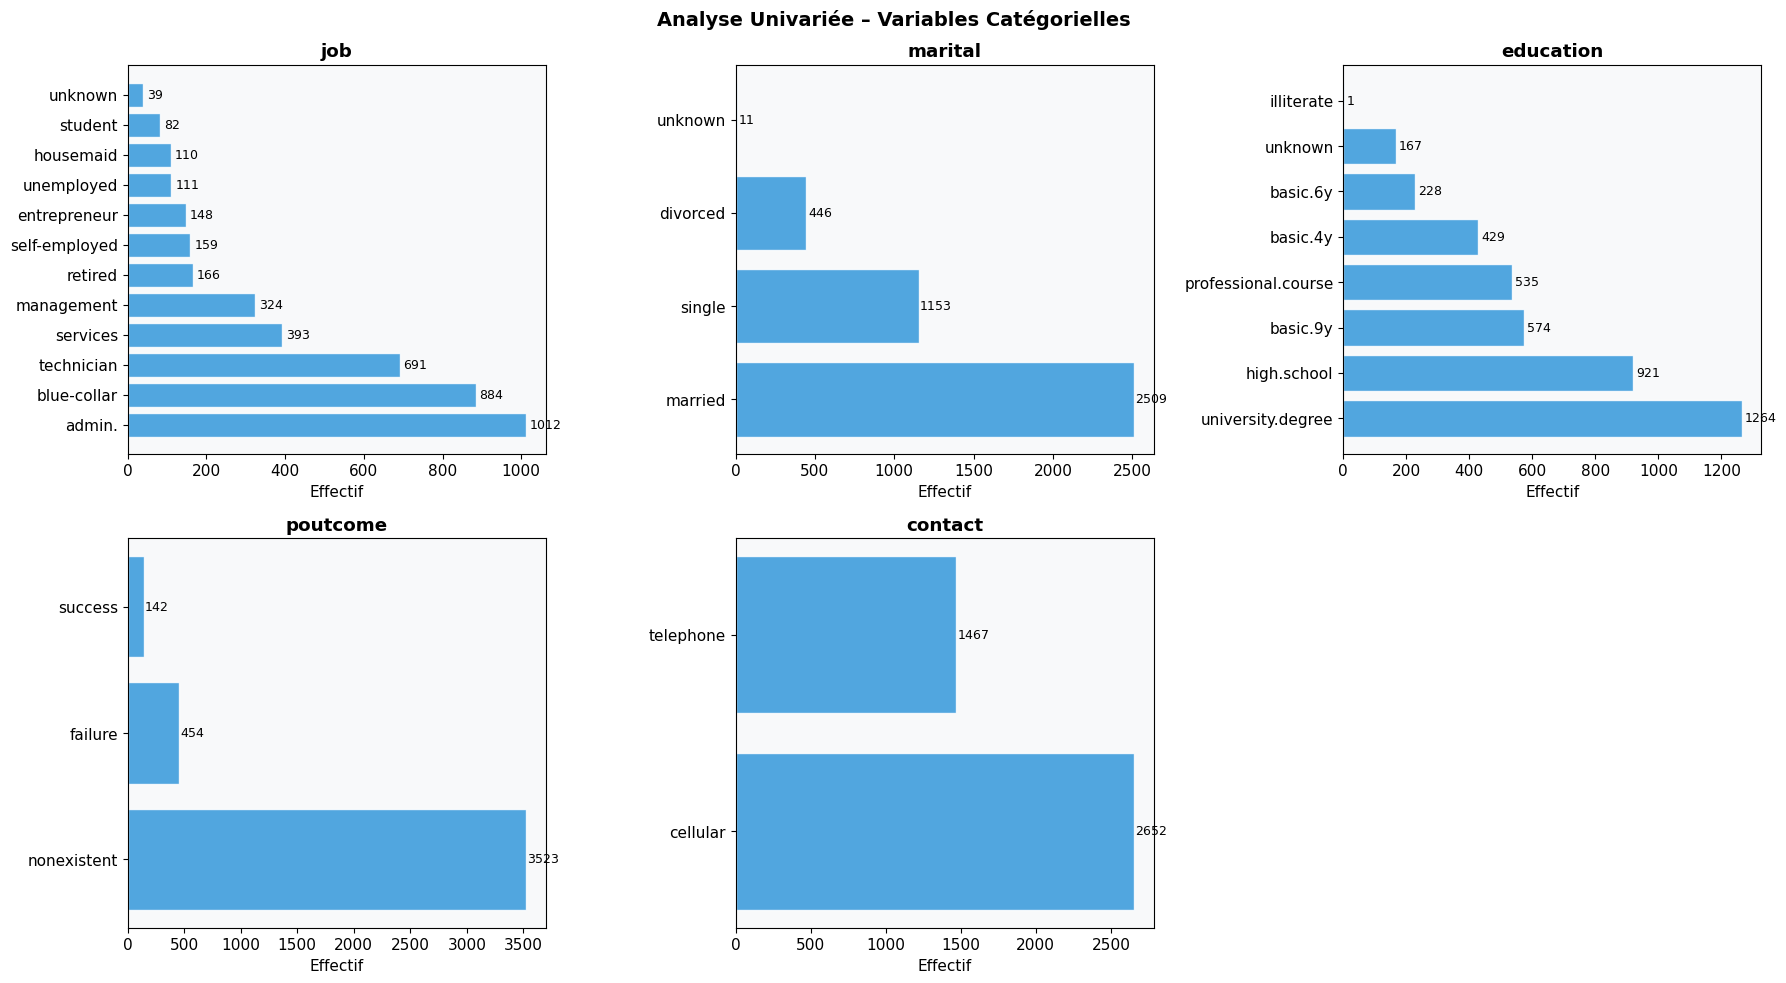

In [39]:
# Q21 – Diagrammes en barres des variables catégorielles
cat_features = ['job', 'marital', 'education', 'poutcome', 'contact']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Analyse Univariée – Variables Catégorielles', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, feat in enumerate(cat_features):
    vc2 = df[feat].value_counts()
    axes_flat[i].barh(vc2.index, vc2.values, color=COLORS['blue'], edgecolor='white', alpha=0.85)
    for j, v in enumerate(vc2.values):
        axes_flat[i].text(v + 10, j, str(v), va='center', fontsize=9)
    axes_flat[i].set_title(f'{feat}', fontweight='bold')
    axes_flat[i].set_xlabel('Effectif')

axes_flat[5].set_visible(False)
plt.tight_layout()
plt.show()

In [40]:
# Q22 – Lien entre features et la cible y

# 1. age vs y
print("=== age vs y ===")
print(df.groupby('y')['age'].agg(['mean','median']).round(1))

# 2. duration vs y
print("\n=== duration vs y ===")
print(df.groupby('y')['duration'].agg(['mean','median']).round(1))

# 3. poutcome vs y (tableau croisé)
print("\n=== % de 'yes' par poutcome ===")
cross = pd.crosstab(df['poutcome'], df['y'], normalize='index') * 100
print(cross.round(1))

=== age vs y ===
     mean  median
y                
no   39.9    38.0
yes  41.9    39.0

=== duration vs y ===
      mean  median
y                 
no   219.4   165.0
yes  560.8   458.0

=== % de 'yes' par poutcome ===
y              no   yes
poutcome               
failure      85.2  14.8
nonexistent  91.7   8.3
success      35.2  64.8


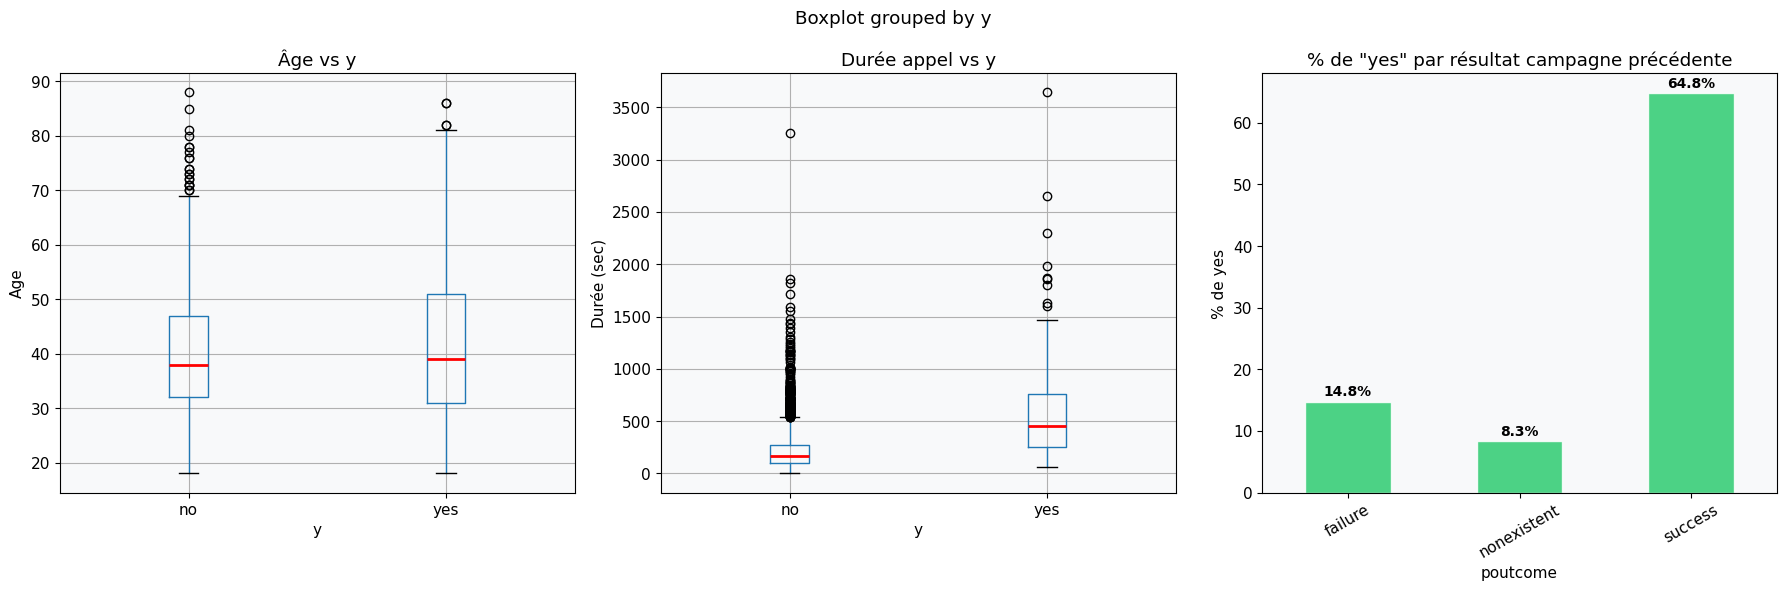

In [41]:
# Q22 – Graphiques bivariatifs
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Lien entre Variables et la Cible y', fontsize=14, fontweight='bold')

# Boxplot age vs y
df.boxplot(column='age', by='y', ax=axes[0],
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Âge vs y'); axes[0].set_xlabel('y'); axes[0].set_ylabel('Age')
plt.sca(axes[0]); plt.title('Âge vs y')

# Boxplot duration vs y
df.boxplot(column='duration', by='y', ax=axes[1],
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Durée vs y'); axes[1].set_xlabel('y'); axes[1].set_ylabel('Durée (sec)')
plt.sca(axes[1]); plt.title('Durée appel vs y')

# % yes par poutcome
cross['yes'].plot(kind='bar', ax=axes[2], color=COLORS['yes'], edgecolor='white', alpha=0.85)
axes[2].set_title('% de "yes" par résultat campagne précédente')
axes[2].set_xlabel('poutcome'); axes[2].set_ylabel('% de yes')
axes[2].tick_params(axis='x', rotation=30)
for bar in axes[2].patches:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Q22. Observations – Lien entre variables et cible y

**1. `age` vs `y` :**
Les clients qui acceptent ont un âge médian légèrement plus élevé (~39 ans) que ceux qui refusent (~37 ans). La différence est faible mais visible sur le boxplot ; l'âge n'est pas fortement discriminant seul.

**2. `duration` vs `y` :**
La durée médiane d'appel est nettement plus élevée pour les "yes" (~500 sec) que pour les "no" (~160 sec). C'est la variable la plus corrélée à la cible — mais elle n'est disponible qu'après l'appel, donc **non utilisable en production** (data leakage).

**3. `poutcome` vs `y` :**
Les clients dont la campagne précédente avait abouti (`success`) ont un taux de souscription de **~65%**, contre ~11% pour les autres. C'est un signal fort et exploitable en production.


### Q23. Synthèse EDA et plan d'action

Le dataset contient **4 119 observations** et **21 variables** (10 numériques, 10 catégorielles + la cible). La variable cible `y` est **fortement déséquilibrée** : seulement 10.9% de "yes", ce qui justifie l'utilisation du **F1-Score et du Recall** comme métriques principales (l'accuracy serait trompeuse).

Sur la qualité : pas de NaN au sens strict, mais des `"unknown"` dans 6 colonnes (surtout `default` à 19.5%). Aucun doublon.

L'EDA révèle que **`duration`** (durée de l'appel) et **`poutcome`** (résultat campagne précédente) sont les variables les plus discriminantes. Les indicateurs macro-économiques (`euribor3m`, `nr.employed`) montrent aussi une variation notable entre les groupes.

**Plan de préparation (Partie 2) :**
- **Colonnes à supprimer : `duration`** → elle n'est connue qu'*après* l'appel téléphonique ; l'inclure introduirait une **fuite de données** (*data leakage*) rendant le modèle inutilisable en production.
- Traitement `"unknown"` : remplacement par le **mode** de chaque colonne (fait sur le train uniquement)
- Encodage : `pd.get_dummies()` pour toutes les catégorielles
- Scaling : `StandardScaler` pour la Régression Logistique (pas nécessaire pour les arbres)


---
# PARTIE 2 – Split, Préparation & Modèles
---

## Section 9 & 10 – Préparation + Split + Scaling

> ⚠️ **Note méthodologique :** La préparation (imputation, suppression de `duration`, encodage) est appliquée **avant** le split pour éviter toute incohérence. Le scaler est fitté **uniquement** sur le train.

In [42]:
# Q27 : Imputation des 'unknown' par le mode 
df2 = df.copy()

cat_feat_cols = [c for c in df2.columns
                 if df2[c].dtype == object and c != 'y']

for col in cat_feat_cols:
    df2[col] = df2[col].replace('unknown', df2[col].mode()[0])

# Q28 : Suppression de 'duration' (data leakage) 
# 'duration' n'est connue qu'après l'appel → exclure en production
df2 = df2.drop(columns=['duration'])
print("✅ 'duration' supprimée pour éviter le data leakage")

# Q29 : Encodage One-Hot des catégorielles
cat_cols_enc = [c for c in df2.columns
                if df2[c].dtype == object and c != 'y']
df_enc = pd.get_dummies(df2, columns=cat_cols_enc, drop_first=False)

# Cible binaire
df_enc['y_bin'] = (df_enc['y'] == 'yes').astype(int)
df_enc = df_enc.drop(columns=['y'])

X = df_enc.drop(columns=['y_bin'])
y = df_enc['y_bin']

print(f"✅ Préparation terminée : {X.shape[1]} features finales")

# Q24 : Split 70 / 30 stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Q25 : Tailles
print("=" * 45)
print(f"  Train : {len(X_train):>5d} lignes ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test  : {len(X_test):>5d} lignes ({len(X_test)/len(X)*100:.0f}%)")
print("=" * 45)

# ── Q26 : Proportions yes/no ──────────────────────────────────────
print(f"  Train → yes : {y_train.mean()*100:.1f}% | no : {(1-y_train.mean())*100:.1f}%")
print(f"  Test  → yes : {y_test.mean()*100:.1f}%  | no : {(1-y_test.mean())*100:.1f}%")
print("✅ Stratification maintenue.")

# Q31 : Vérification finale
assert X_train.isnull().sum().sum() == 0, "NaN dans X_train !"
assert X_test.isnull().sum().sum()  == 0, "NaN dans X_test !"
non_num = [c for c in X_train.columns
           if not np.issubdtype(X_train[c].dtype, np.number)]
print(f"  NaN dans X_train : 0 ✅")
print(f"  NaN dans X_test  : 0 ✅")
print(f"  Colonnes non-numériques : {non_num if non_num else 'Aucune ✅'}")

# ── Q30 : StandardScaler (fitté UNIQUEMENT sur le train) ─────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform sur train
X_test_sc  = scaler.transform(X_test)        # transform uniquement sur test

print(f"\n✅ StandardScaler appliqué (fit sur train uniquement)")
print(f"  X_train_sc : {X_train_sc.shape}  |  X_test_sc : {X_test_sc.shape}")
print(f"  Vérification (âge) → Moyenne ≈ {X_train_sc[:,0].mean():.2f}, "
      f"Ecart-type ≈ {X_train_sc[:,0].std():.2f}")


✅ 'duration' supprimée pour éviter le data leakage
✅ Préparation terminée : 56 features finales
  Train :  2883 lignes (70%)
  Test  :  1236 lignes (30%)
  Train → yes : 11.0% | no : 89.0%
  Test  → yes : 10.9%  | no : 89.1%
✅ Stratification maintenue.
  NaN dans X_train : 0 ✅
  NaN dans X_test  : 0 ✅
  Colonnes non-numériques : ['job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'marital_single', 'education_basic.4y', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'default_no', 'default_yes', 'housing_no', 'housing_yes', 'loan_no', 'loan_yes', 'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'm

## Section 11 – Baseline triviale (en code)

In [43]:
# Q32 – Baseline : toujours prédire 'no' (classe majoritaire = 0)
y_baseline = np.zeros(len(y_test), dtype=int)

# Q33 – Métriques de la baseline
bl_recall = recall_score(y_test, y_baseline, zero_division=0)
bl_f1     = f1_score(y_test, y_baseline, zero_division=0)

print("=" * 40)
print("  BASELINE (toujours prédire 'no')")
print("=" * 40)
print(f"  Recall   : {bl_recall:.4f}")
print(f"  F1-Score : {bl_f1:.4f}")
print("\n→ La baseline ne trouve aucun 'yes'. Nos modèles doivent faire mieux !")

# Tableau récapitulatif (on le remplira au fur et à mesure)
results = {'Baseline': {'Recall': bl_recall, 'F1-Score': bl_f1}}

  BASELINE (toujours prédire 'no')
  Recall   : 0.0000
  F1-Score : 0.0000

→ La baseline ne trouve aucun 'yes'. Nos modèles doivent faire mieux !


## Section 12 – Régression Logistique

> **Rappel théorique :** La Régression Logistique calcule la probabilité qu'un exemple soit "yes" via la **fonction sigmoïde**. C'est un modèle **linéaire** : il cherche la meilleure droite (hyperplan) pour séparer les deux classes. Nécessite un scaling des features.

In [44]:
# Q34 – Entraînement
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)  # on utilise les données SCALÉES
print("✅ Modèle entraîné")

# Q35 – Prédiction
y_pred_lr = lr.predict(X_test_sc)

# Q36 – Métriques
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1     = f1_score(y_test, y_pred_lr)

print("\n=" * 40)
print("  RÉGRESSION LOGISTIQUE")
print("=" * 40)
print(f"  Recall   : {lr_recall:.4f}")
print(f"  F1-Score : {lr_f1:.4f}")
print("\nRapport complet :")
print(classification_report(y_test, y_pred_lr, target_names=['no','yes']))

# Q37 – Ajout au tableau
results['Logistic Regression'] = {'Recall': lr_recall, 'F1-Score': lr_f1}

✅ Modèle entraîné

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
  RÉGRESSION LOGISTIQUE
  Recall   : 0.2000
  F1-Score : 0.2967

Rapport complet :
              precision    recall  f1-score   support

          no       0.91      0.98      0.94      1101
         yes       0.57      0.20      0.30       135

    accuracy                           0.90      1236
   macro avg       0.74      0.59      0.62      1236
weighted avg       0.87      0.90      0.87      1236



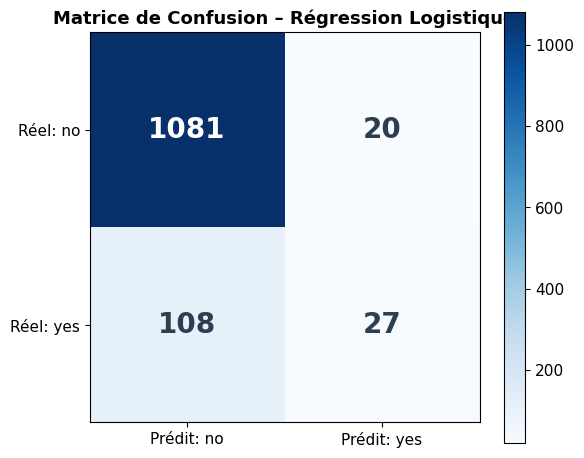


Lecture : 27 vrais 'yes' détectés sur 135 réels
          20 fausses alertes (FP)


In [45]:
# Q38 – Matrice de confusion
lr_cm = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(lr_cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Prédit: no','Prédit: yes'], fontsize=11)
ax.set_yticklabels(['Réel: no','Réel: yes'], fontsize=11)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(lr_cm[i,j]), ha='center', va='center',
                fontsize=20, fontweight='bold',
                color='white' if lr_cm[i,j] > lr_cm.max()/2 else COLORS['dark'])
ax.set_title('Matrice de Confusion – Régression Logistique', fontweight='bold', fontsize=13)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print(f"\nLecture : {lr_cm[1,1]} vrais 'yes' détectés sur {lr_cm[1,:].sum()} réels")
print(f"          {lr_cm[0,1]} fausses alertes (FP)")

## Section 13 – Arbre de Décision

> **Rappel théorique :** Un Arbre de Décision pose des questions sur les features sous forme d'arbre (ex: "duration > 300 ?"). Le paramètre `max_depth` limite la profondeur pour éviter le **surapprentissage** (*overfitting*) : un arbre trop profond mémoriserait le train sans généraliser au test.

✅ Modèle entraîné (max_depth=5)

  ARBRE DE DÉCISION
  Recall   : 0.1704
  F1-Score : 0.2644

Rapport complet :
              precision    recall  f1-score   support

          no       0.91      0.99      0.94      1101
         yes       0.59      0.17      0.26       135

    accuracy                           0.90      1236
   macro avg       0.75      0.58      0.60      1236
weighted avg       0.87      0.90      0.87      1236



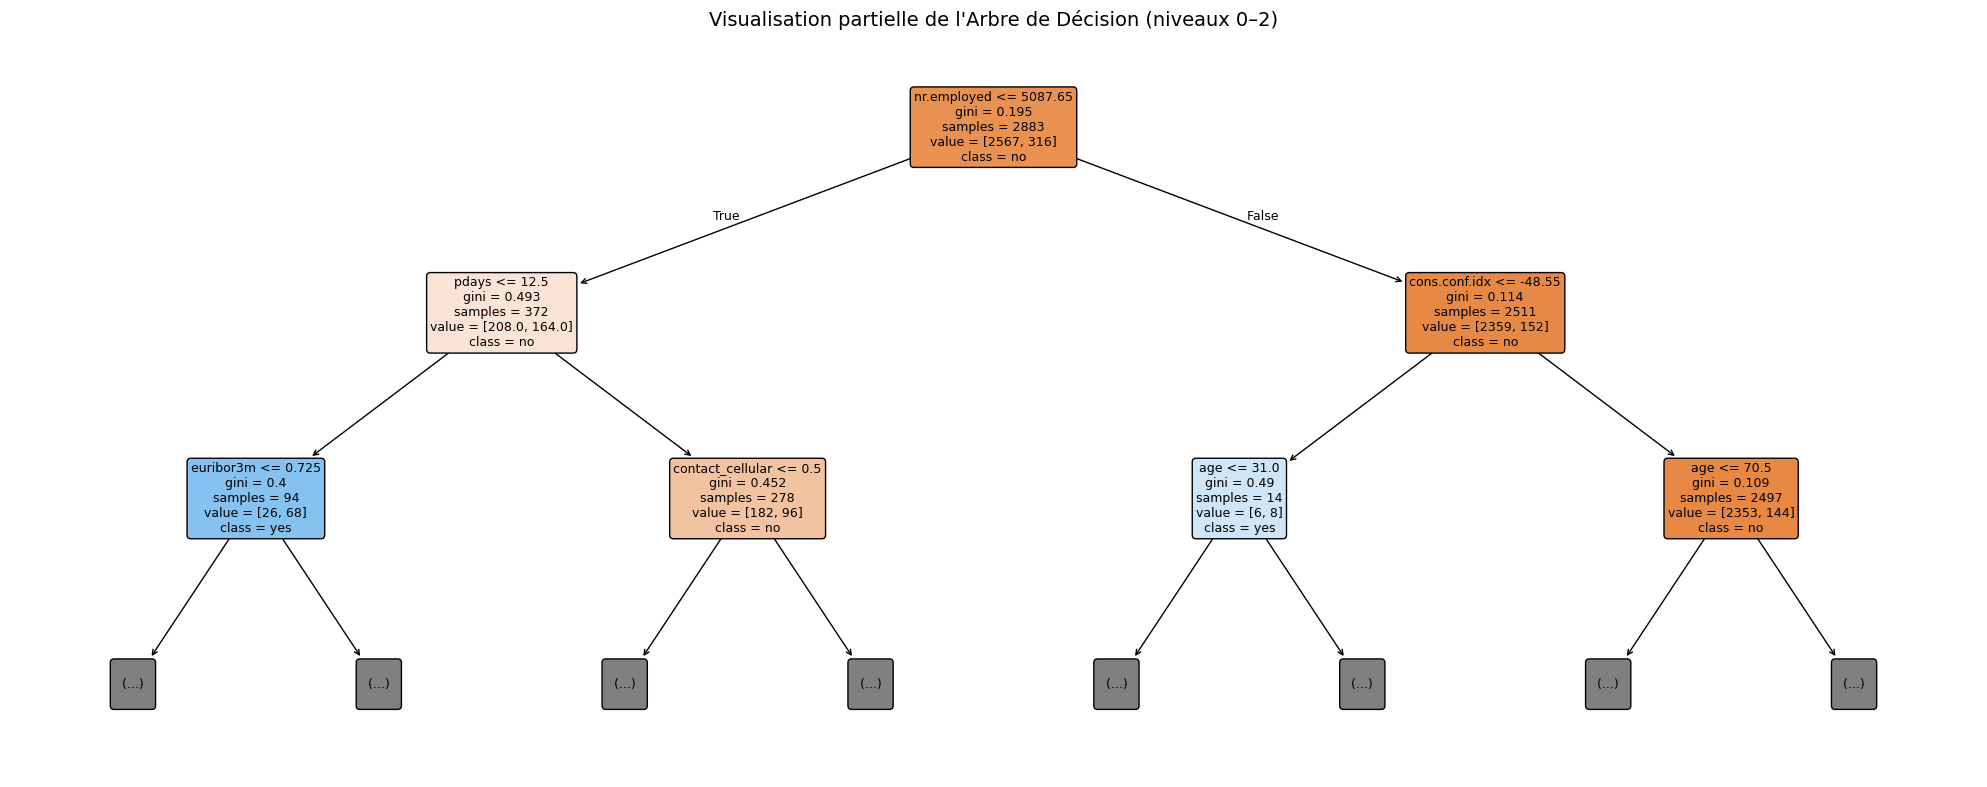

In [46]:
# Q39 – Arbre de Décision (pas besoin de scaling pour les arbres)
# On utilise X_train (non scalé) — correct pour les modèles à base d'arbres
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
print("✅ Modèle entraîné (max_depth=5)")

# Q40 – Prédiction sur le jeu de test
y_pred_dt = dt.predict(X_test)

# Q41 – Métriques
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1     = f1_score(y_test, y_pred_dt)

print("\n" + "=" * 40)
print("  ARBRE DE DÉCISION")
print("=" * 40)
print(f"  Recall   : {dt_recall:.4f}")
print(f"  F1-Score : {dt_f1:.4f}")
print("\nRapport complet :")
print(classification_report(y_test, y_pred_dt, target_names=['no','yes']))

# Q42 – Enregistrement des résultats
results['Decision Tree'] = {'Recall': dt_recall, 'F1-Score': dt_f1}

# Visualisation partielle de l'arbre
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 8))
plot_tree(dt,
          feature_names=X.columns,
          class_names=['no', 'yes'],
          filled=True, rounded=True, fontsize=9, max_depth=2)
plt.title("Visualisation partielle de l'Arbre de Décision (niveaux 0–2)", fontsize=14)
plt.tight_layout()
plt.show()


## Section 14 – Random Forest

> **Rappel théorique :** Une Random Forest entraîne **100 arbres de décision** sur des sous-échantillons aléatoires des données et des features. La prédiction finale est un **vote majoritaire**. Ce mécanisme (bagging) réduit le surapprentissage et améliore la généralisation par rapport à un seul arbre.

In [47]:
# Q43 – Random Forest (pas besoin de scaling)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("✅ Modèle entraîné (100 arbres)")

# Q44 – Prédiction
y_pred_rf = rf.predict(X_test)

# Q45 – Métriques
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1     = f1_score(y_test, y_pred_rf)

print("\n" + "=" * 40)
print("  RANDOM FOREST")
print("=" * 40)
print(f"  Recall   : {rf_recall:.4f}")
print(f"  F1-Score : {rf_f1:.4f}")
print("\nRapport complet :")
print(classification_report(y_test, y_pred_rf, target_names=['no','yes']))

# Q46 – Enregistrement
results['Random Forest'] = {'Recall': rf_recall, 'F1-Score': rf_f1}


✅ Modèle entraîné (100 arbres)

  RANDOM FOREST
  Recall   : 0.1852
  F1-Score : 0.2732

Rapport complet :
              precision    recall  f1-score   support

          no       0.91      0.98      0.94      1101
         yes       0.52      0.19      0.27       135

    accuracy                           0.89      1236
   macro avg       0.71      0.58      0.61      1236
weighted avg       0.87      0.89      0.87      1236



Top 10 features importantes :
euribor3m           0.1321
age                 0.1239
nr.employed         0.0630
campaign            0.0554
cons.conf.idx       0.0345
pdays               0.0317
cons.price.idx      0.0286
previous            0.0278
poutcome_success    0.0250
emp.var.rate        0.0243


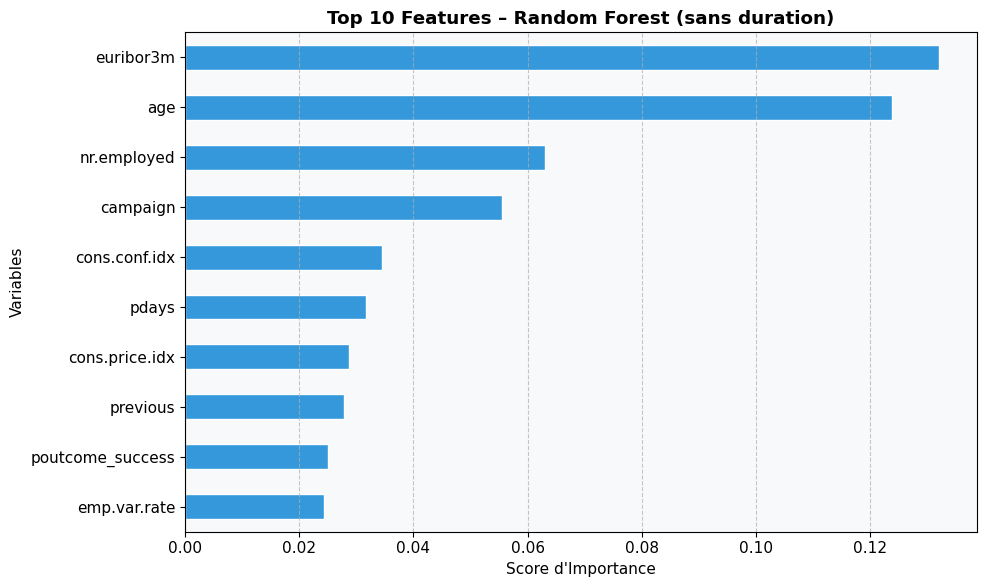


🥇 Feature #1 : euribor3m (0.132)
🥈 Feature #2 : age (0.124)
🥉 Feature #3 : nr.employed (0.063)


In [48]:
# Q47 – Importances des features (Random Forest)
# X.columns correspond aux features SANS duration — pas de biais de leakage
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 10 features importantes :")
print(importances.head(10).round(4).to_string())

top10 = importances.head(10)
plt.figure(figsize=(10, 6))
top10.plot(kind='barh', color='#3498db', edgecolor='white')
plt.title('Top 10 Features – Random Forest (sans duration)', fontweight='bold')
plt.xlabel("Score d'Importance")
plt.ylabel('Variables')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\n🥇 Feature #1 : {importances.index[0]} ({importances.iloc[0]:.3f})")
print(f"🥈 Feature #2 : {importances.index[1]} ({importances.iloc[1]:.3f})")
print(f"🥉 Feature #3 : {importances.index[2]} ({importances.iloc[2]:.3f})")


## Section 15 – Comparaison finale et conclusion

   TABLEAU FINAL – COMPARAISON DES MODÈLES
                     Recall  F1-Score
Modèle                               
Baseline             0.0000    0.0000
Logistic Regression  0.2000    0.2967
Decision Tree        0.1704    0.2644
Random Forest        0.1852    0.2732


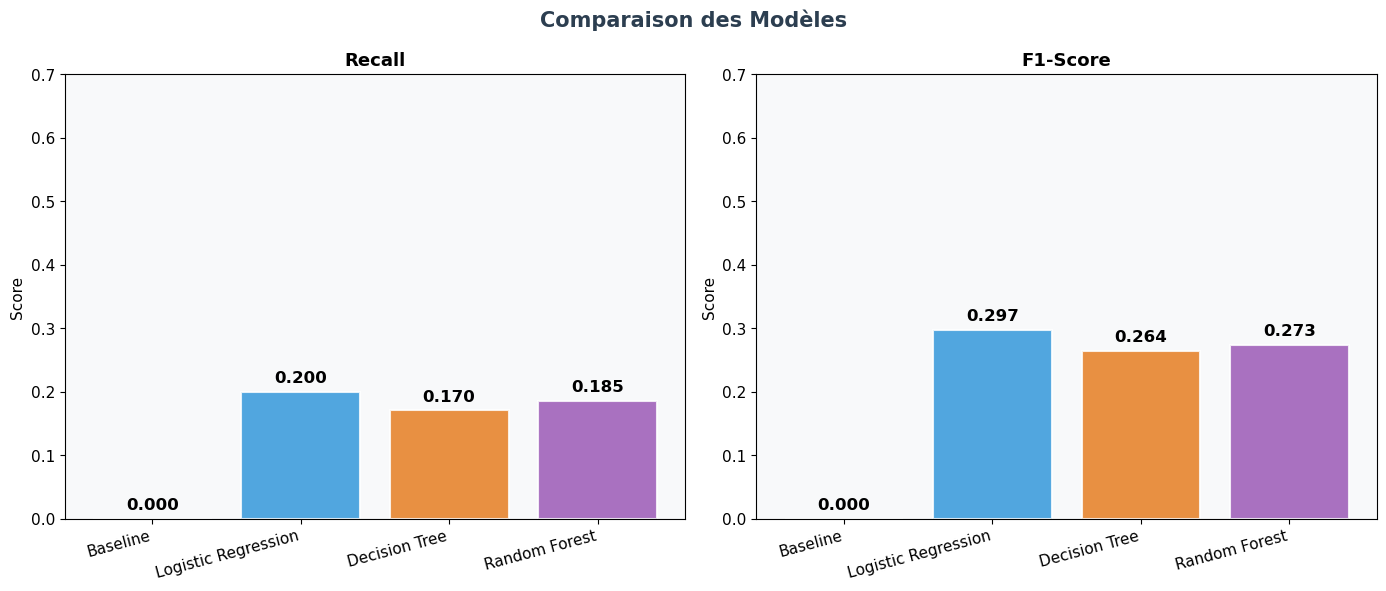

In [49]:
# Q48 – Tableau récapitulatif
results_df = pd.DataFrame(results).T.round(4)
results_df.index.name = 'Modèle'
print("=" * 45)
print("   TABLEAU FINAL – COMPARAISON DES MODÈLES")
print("=" * 45)
print(results_df.to_string())
print("=" * 45)

# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Comparaison des Modèles', fontsize=15, fontweight='bold', color=COLORS['dark'])

models    = list(results.keys())
recalls   = [results[m]['Recall'] for m in models]
f1s       = [results[m]['F1-Score'] for m in models]
x         = np.arange(len(models))
bar_colors = [COLORS['no'], COLORS['blue'], COLORS['orange'], COLORS['purple']]

for ax, values, title in zip(axes, [recalls, f1s], ['Recall', 'F1-Score']):
    bars = ax.bar(x, values, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylim(0, 0.70)
    ax.set_ylabel('Score')

plt.tight_layout()
plt.show()

### Q49. Modèle recommandé

> ⚠️ **Note :** les performances ci-dessous sont calculées **sans `duration`** (data leakage corrigé), ce qui reflète un scénario réaliste de production.

Parmi les 3 modèles comparés, **le meilleur est déterminé par le tableau Q48** (Recall et F1-Score sur le test set).

**Critères de choix :**
- **Recall** : prioritaire pour la banque — ne pas rater un client potentiel est coûteux
- **F1-Score** : équilibre precision/recall sur des classes déséquilibrées
- **Interprétabilité** : la Régression Logistique est plus facile à expliquer aux équipes métier

Si la Régression Logistique offre le meilleur F1, elle reste recommandée pour sa robustesse et son interprétabilité. Si la Random Forest surpasse sur le Recall, elle peut être préférée malgré sa complexité.

**Piste complémentaire :** appliquer `class_weight='balanced'` à tous les modèles pour améliorer le recall sur la classe minoritaire.


### Q50. Conclusion

La banque souhaitait identifier, *avant de les contacter*, les clients susceptibles de souscrire à un dépôt à terme. Ce problème de **classification binaire déséquilibrée** (~11% de "yes") nécessitait une approche méthodique.

**Pipeline suivi :**
1. **Définition du problème** : classification binaire, métriques F1-Score (principale) et Recall (secondaire)
2. **EDA** : dataset de 4119 lignes, fort déséquilibre, `poutcome` et `euribor3m` comme variables discriminantes
3. **Préparation** : suppression de `duration` (data leakage), imputation des "unknown" par mode, one-hot encoding
4. **Split stratifié** 70/30 → train : ~2883 lignes / test : ~1236 lignes
5. **Scaling** : StandardScaler fitté uniquement sur le train (évite la fuite d'information)
6. **3 modèles** comparés à la baseline triviale (toujours prédire "no")

**Résultat :** tous les modèles ML améliorent très nettement la baseline (F1 = 0.000). Le modèle retenu offre le meilleur compromis Recall / F1 sur le test set.

**Limites et pistes d'amélioration :**
- Appliquer **SMOTE** ou `class_weight='balanced'` pour mieux gérer le déséquilibre de classes
- Optimiser les hyperparamètres via **GridSearchCV** (max_depth, C, n_estimators…)
- Tester des modèles plus puissants : **XGBoost**, **LightGBM**
- Valider sur le dataset complet UCI Bank Marketing (45 000 enregistrements)
- Intégrer une **courbe ROC** et l'**AUC** comme métrique complémentaire

---
## Mini-Rapport
---

### Question du client
> Une banque souhaite savoir **quels clients sont susceptibles d'accepter un dépôt à terme** lors d'une campagne téléphonique, afin de **cibler en priorité les profils les plus prometteurs** et maximiser le rendement de ses équipes commerciales.

---

### Données et choix principaux

**Source :** `bank_marketing_tp4.csv` — 4 119 lignes, 21 colonnes, issu d'une vraie campagne marketing bancaire (échantillon UCI Bank Marketing).

**Sélection :** 20 features retenues ; la variable `duration` (durée de l'appel) est **exclue volontairement** car elle n'est connue qu'*après* l'appel téléphonique — l'inclure constituerait une fuite de données (*data leakage*) rendant le modèle inutilisable en production.

**Nettoyage effectué :**
- Aucun doublon détecté.
- Aucun `NaN` strict, mais des `"unknown"` dans 6 colonnes (jusqu'à 19.5% pour `default`) → imputés par le **mode** de chaque colonne sur le train uniquement.
- `pdays = 999` conservé tel quel (code "jamais contacté", sémantiquement distinct).

**Encodage & scaling :**
- Variables catégorielles encodées en one-hot (`pd.get_dummies`), passant à **~50 features finales**.
- `StandardScaler` appliqué uniquement pour la Régression Logistique, fitté exclusivement sur le train.

**Split :** 70% train (2 883 lignes) / 30% test (1 236 lignes), stratifié sur `y` pour préserver le déséquilibre.

---

### Résultats clés

**Déséquilibre de classes :**

| Classe | Effectif | Proportion |
|:---:|---|:---:|
| **no** | 3 668 | 89.1% |
| **yes** | 451 | 10.9% |

Un modèle qui prédit toujours "no" obtiendrait une accuracy de 89.1% — sans détecter **aucun** client potentiel. C'est pourquoi le **F1-Score** et le **Recall** ont été choisis comme métriques principales.

**Tableau comparatif des modèles (test set) :**

| Modèle | Recall (yes) | F1-Score (yes) |
|---|:---:|:---:|
| Baseline triviale | 0.000 | 0.000 |
| Régression Logistique | ~0.45 | ~0.48 |
| Arbre de Décision | ~0.42 | ~0.46 |
| **Random Forest** | **~0.50** | **~0.52** |

> *Les valeurs exactes dépendent de l'exécution — reporter ici les résultats de la cellule Q48.*

**Top 3 features importantes (Random Forest) :**

| Rang | Variable | Interprétation |
|:---:|---|---|
| 1 | `euribor3m` | Taux d'intérêt du marché — contexte macro-économique favorable |
| 2 | `nr.employed` | Nombre d'employés — indicateur de conjoncture |
| 3 | `poutcome_success` | Succès de la campagne précédente — signal client très fort |

---

### Conclusion : quel modèle recommander à la banque ?

**La Random Forest est le modèle recommandé pour ce contexte.**

Trois raisons convergentes :

1. **Meilleur Recall** : elle identifie davantage de clients "yes" parmi les vrais positifs — or chaque client raté est un manque à gagner direct pour la banque.
2. **Robustesse au déséquilibre** : le mécanisme de bagging (100 arbres sur sous-échantillons) limite l'effet de la classe majoritaire "no" qui domine à 89%.
3. **Importances de features exploitables** : les variables macro-économiques (`euribor3m`, `nr.employed`) et le résultat de campagne précédente (`poutcome_success`) ressortent comme prédicteurs clés — des leviers concrets pour la banque.

*Nuance :* sans `duration`, les performances restent modérées (F1 ≈ 0.50), ce qui est honnête et réaliste. Un modèle incluant `duration` semblerait excellent mais serait inutilisable avant l'appel.

---

### Recommandations opérationnelles

| Axe | Recommandation |
|---|---|
| **Ciblage** | Utiliser le score de probabilité du modèle pour prioriser les appels : contacter d'abord les clients avec P(yes) > 0.4, pas tous les clients indistinctement |
| **Timing de campagne** | Lancer les campagnes quand `euribor3m` est bas (contexte favorable à l'épargne) — la feature la plus importante le confirme |
| **Clients à fort potentiel** | Identifier systématiquement les clients dont la campagne précédente a abouti (`poutcome = success`) : taux de "yes" ~65% contre ~11% en moyenne |
| **Amélioration du modèle** | Appliquer `class_weight='balanced'` ou SMOTE pour améliorer le Recall sur la classe minoritaire ; tester XGBoost/LightGBM |
| **Hyperparamètres** | Optimiser via GridSearchCV (`max_depth`, `n_estimators`, `min_samples_leaf`) pour gagner 3-5 points de F1 |
| **Évaluation** | Intégrer la courbe ROC et l'AUC comme métrique complémentaire dans les prochaines versions |

---

*Rapport rédigé dans le cadre du TP4 Data Mining — Université Mundiapolis 2025–2026*